# Model 4 - Random Forest

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier

In [4]:
df = pd.read_csv("./datasets/Heart_Disease_Indicators.csv")

In [5]:
X = df.drop(["HeartDiseaseorAttack"], axis=1)
y = df["HeartDiseaseorAttack"]

In [6]:
feature_names = [c for c in df.columns if c != "HeartDiseaseorAttack"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [8]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [9]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

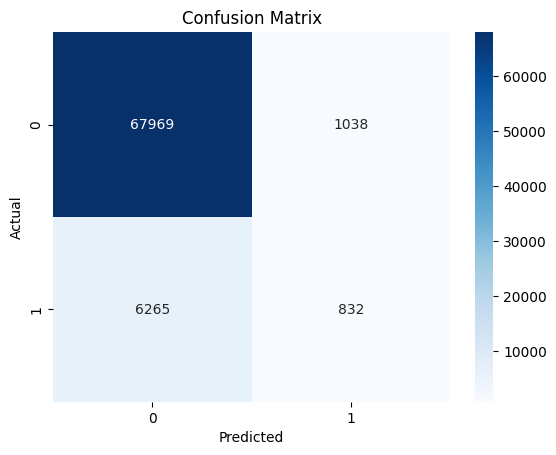

In [10]:
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

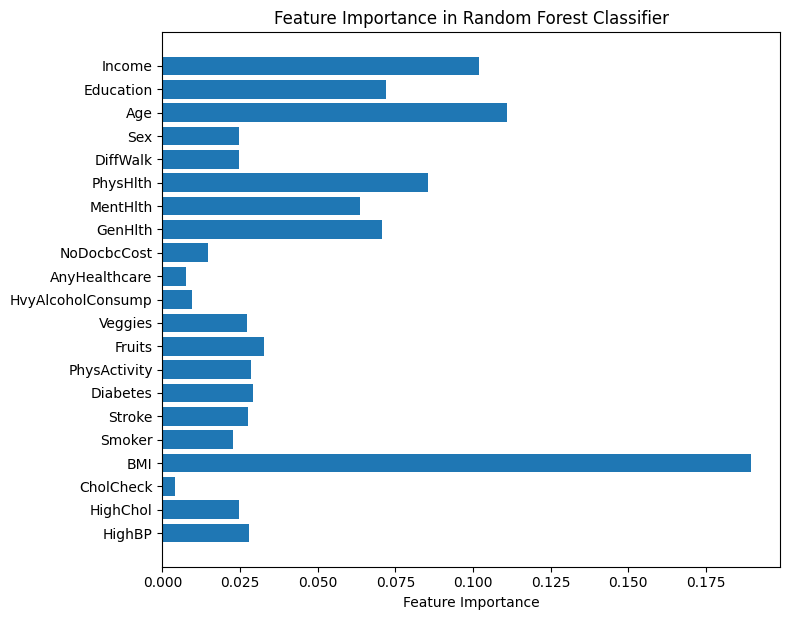

In [ ]:
feature_importances = model.feature_importances_

plt.figure(figsize=(8, max(4, len(feature_names) * 0.3)))
plt.barh(feature_names, feature_importances)
plt.xlabel("Feature Importance")
plt.title("Feature Importance in Random Forest Classifier")
plt.tight_layout()
plt.show()

In [12]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.92      0.98      0.95     69007
         1.0       0.44      0.12      0.19      7097

    accuracy                           0.90     76104
   macro avg       0.68      0.55      0.57     76104
weighted avg       0.87      0.90      0.88     76104



# Picke File

In [13]:
with open('./model-4.pkl', 'wb') as f:
    pickle.dump(model, f)

In [14]:
with open('./model-4.pkl', 'rb') as f:
    loaded_model = pickle.load(f)